## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [1]:
# Installing the libraries with the specified version.
#!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [116]:
import numpy as np
import pandas as pd
#from sklearn.model_selection import train_test_split
#from sklearn.tree import DecisionTreeClassifier
#from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

RS=0

import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [3]:
data = pd.read_csv('Loan_Modelling.csv')

## Data Overview

* Observations
* Sanity checks

In [ ]:
data.shape

(5000, 14)

- Data has 5000 rows and 14 columns

In [96]:
# //pd.DataFrame({'Count':data.isnull().sum()[data.isnull().sum()>0],'Percentage':(data.isnull().sum()[data.isnull().sum()>0]/data.shape[0])*100})
data.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

- Data doesn't have any null values so missing data treatment isn't needed

In [15]:
data.describe()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [97]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [73]:
print("number of unique zip codes:", len(data['ZIPCode'].unique()))

number of unique zip codes: 467


- -3 years of experience?

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

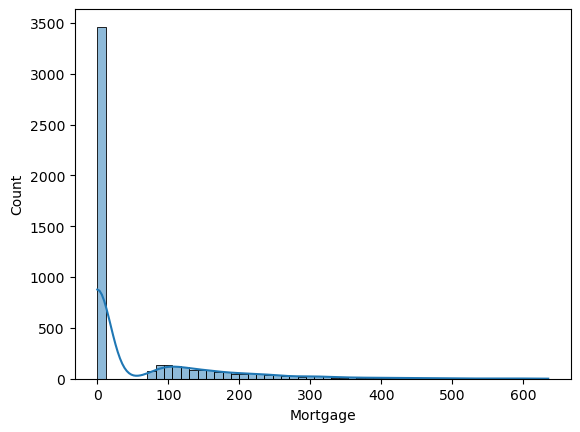

In [22]:
sns.histplot(data=data,x='Mortgage', kde=True);


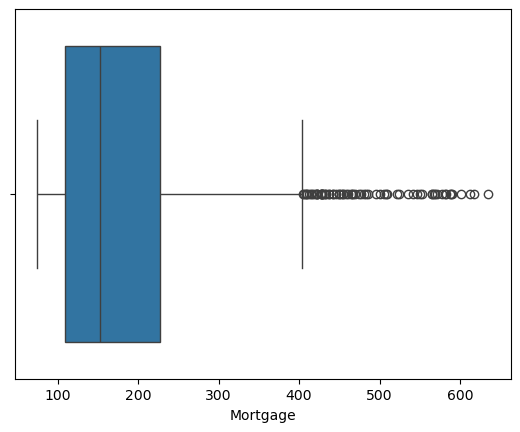

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,1538.000000,1538.000000,1538.000000,1538.000000,1538.000000,1538.000000,1538.000000,1538.000000,1538.000000,1538.000000,1538.000000,1538.000000,1538.000000,1538.000000
mean,2459.231469,45.174252,19.958388,73.519506,93186.334850,2.405072,1.908056,1.880364,183.676203,0.109233,0.103381,0.074772,0.593628,0.290637
std,1410.595647,11.428636,11.417873,47.303722,1753.386518,1.138045,1.744524,0.842120,101.361226,0.312032,0.304555,0.263109,0.491315,0.454204
min,6.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,75.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1277.250000,35.000000,10.000000,38.000000,92008.000000,1.000000,0.700000,1.000000,109.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2437.500000,45.000000,20.000000,62.000000,93422.000000,2.000000,1.500000,2.000000,153.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,3629.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,227.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,4997.000000,67.000000,43.000000,205.000000,96651.000000,4.000000,9.000000,3.000000,635.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [25]:
data_nonzero_mortgage = data[data['Mortgage'] > 0]
sns.boxplot(data=data_nonzero_mortgage,x='Mortgage')
plt.show()
data_nonzero_mortgage.describe()

In [75]:
num_with_cc = len(data[data['CCAvg']>0])
num_without_cc = len(data[data['CCAvg']<=0])
num_with_other_bank_cc = len(data[data['CreditCard']==1])
num_without_other_bank_cc = len(data[data['CreditCard']==0])

print("with All Life CC:", num_with_cc)
print("without All Life CC:", num_without_cc)
print("with other bank CC:", num_with_other_bank_cc)
print("without other bank CC:", num_without_other_bank_cc)

with All Life CC: 4894
without All Life CC: 106
with other bank CC: 1470
without other bank CC: 3530


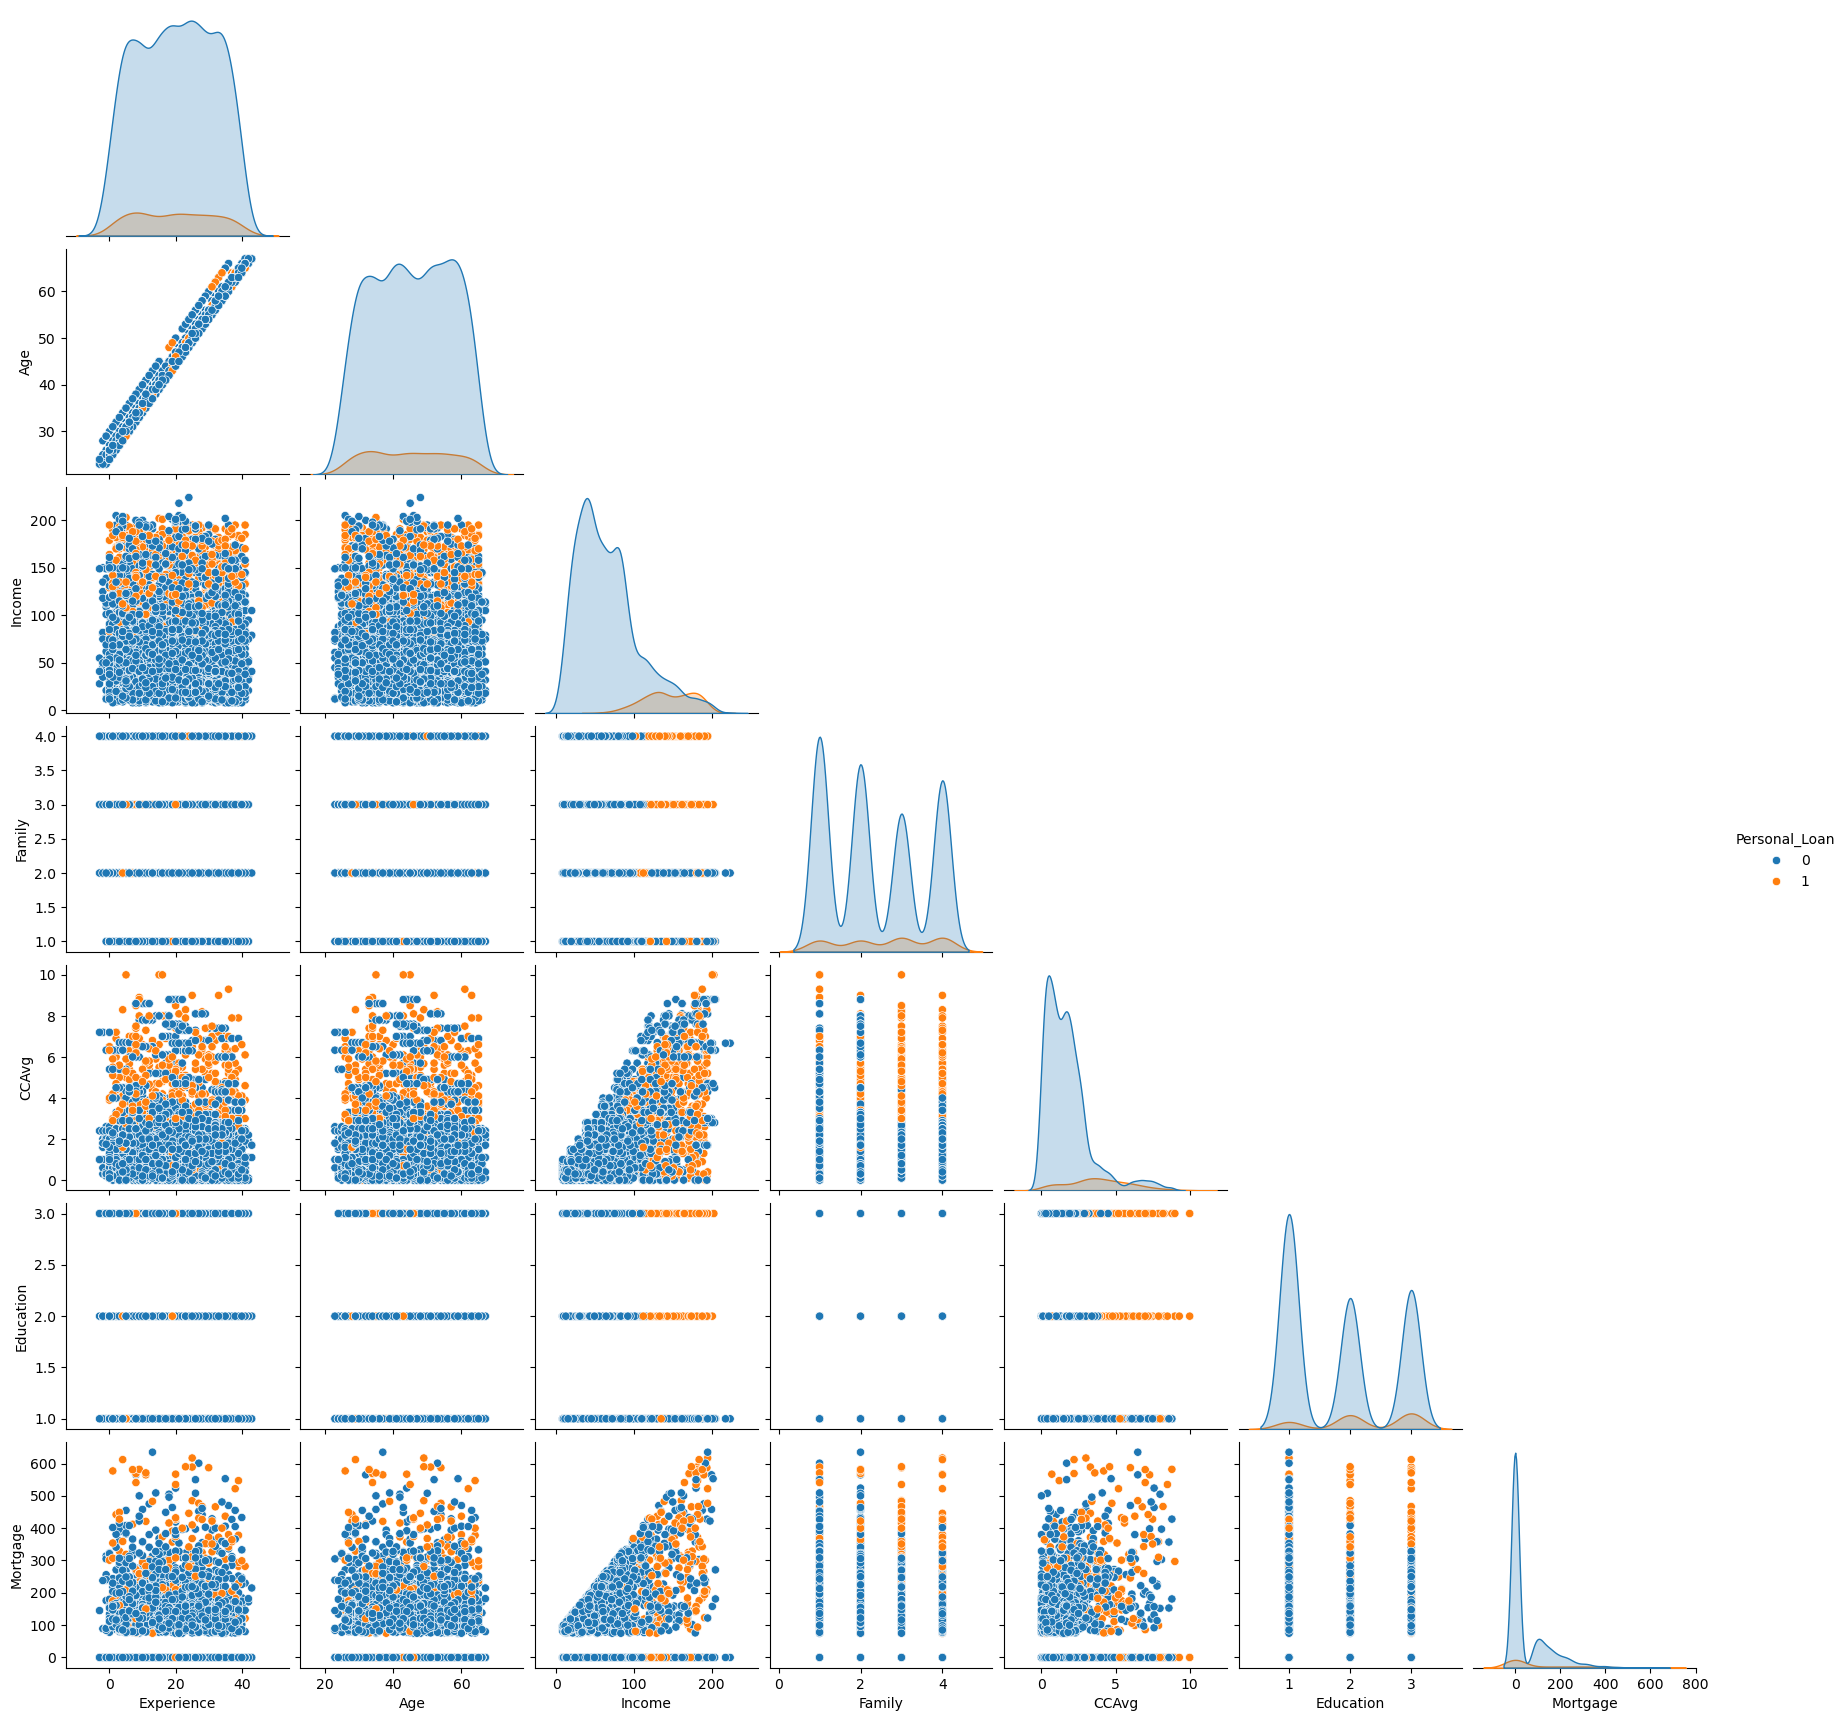

In [41]:
#make a scatterplot
#sns.scatterplot(data=data, x='engine_size', y='horsepower', hue='fuel_type', style='fuel_type')
#make a pairplot
sns.pairplot(data=data, vars=['Experience', 'Age', 'Income', 'Family', 'CCAvg', 
                              'Education', 'Mortgage'], hue='Personal_Loan', corner=True);

<Axes: xlabel='Family', ylabel='count'>

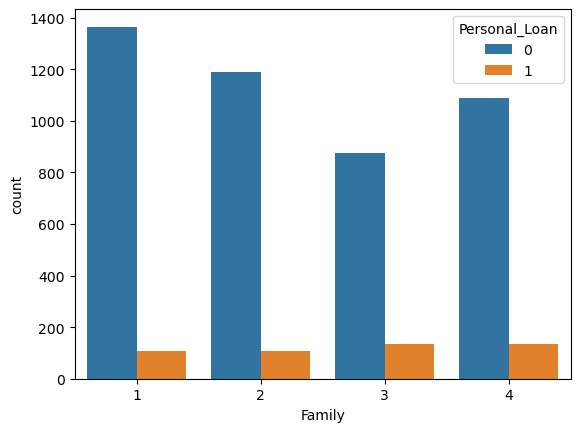

In [51]:
sns.countplot(data=data, x='Family', hue='Personal_Loan')

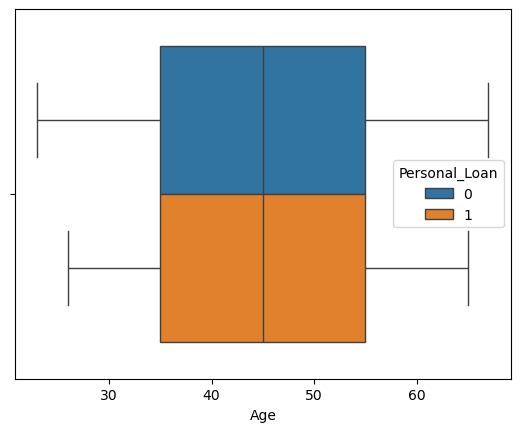

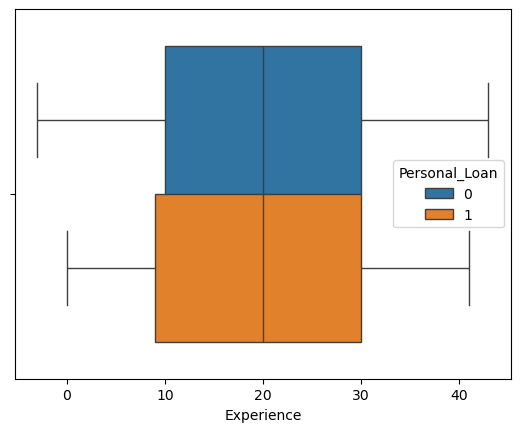

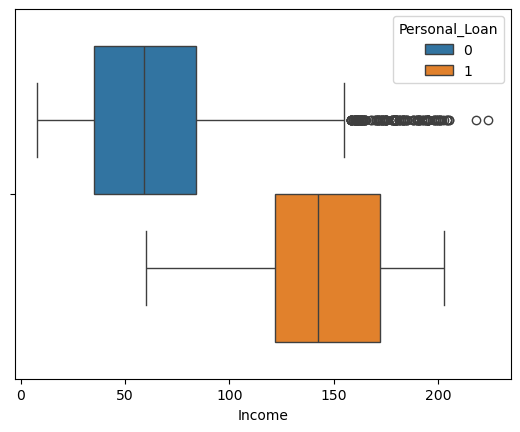

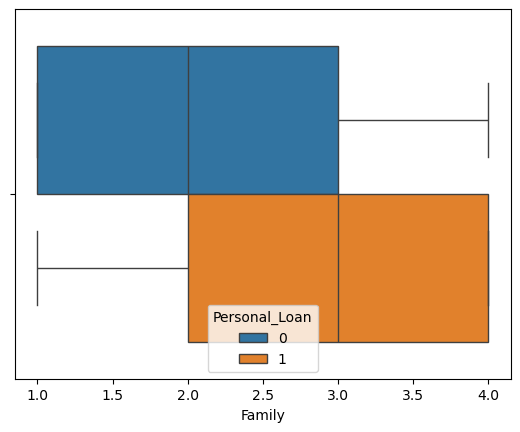

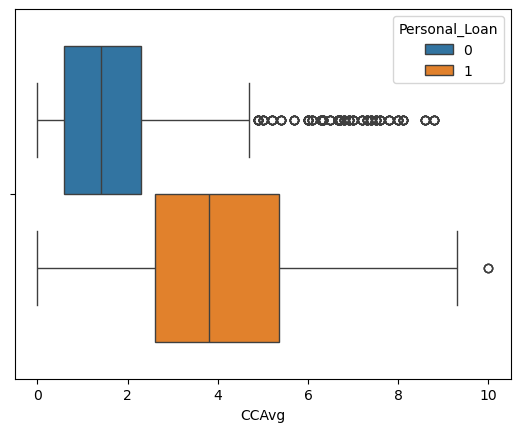

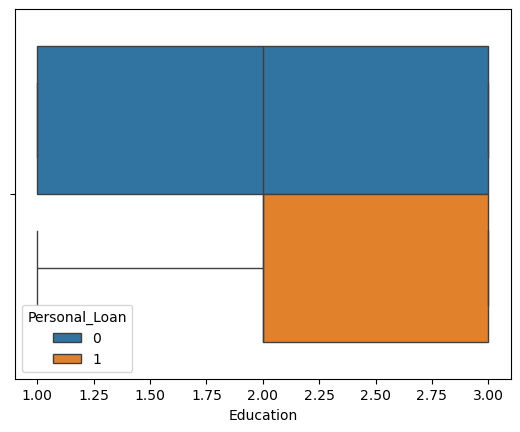

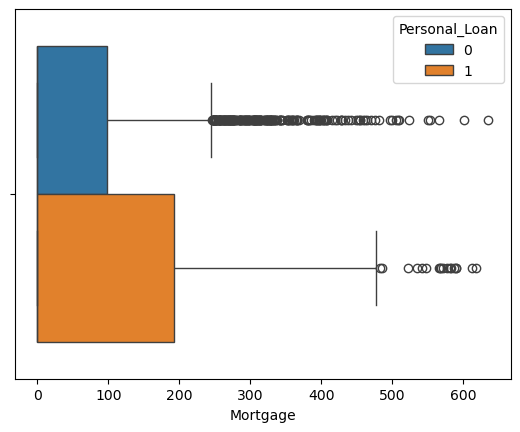

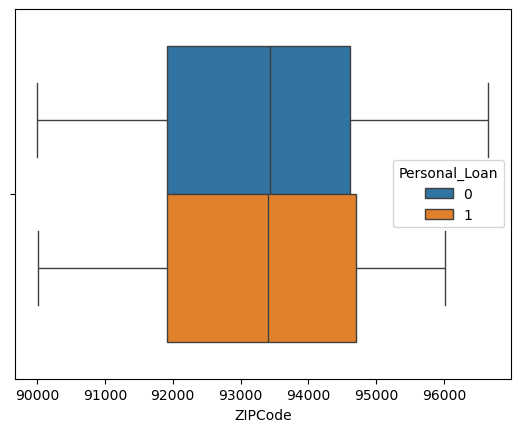

In [66]:
#sns.histplot(data=data, x='CCAvg', bins=20, hue='Personal_Loan', kde=True);
columns = ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', "ZIPCode"]
# print('cols:', columns)
for col in columns:
    sns.boxplot(data=data,x=col,hue='Personal_Loan')
    plt.show()
# sns.boxplot(data=data,x='CCAvg',hue='Personal_Loan')
# plt.show()
# sns.boxplot(data=data,x='Age',hue='Personal_Loan')
# plt.show()

In [ ]:
#TODO: see histogram_boxplot and labeled_barplot in MLS3 notebook
#univariate analysis is more important than bivariate analysis

- Most customers do not have a mortgage, as expected.
- Most customers that do have mortgages are around $100k and are right-skewed toward $600 thousand.
- For customers that do have a mortgage, the mean amount is $184k, with the min and max being $75k and $635k, respectively.
- 4894 customers are using an All Life Bank CC and 106 customers are not.
- 1470 customers use a CC from another bank and 3530 customers do not.
- The box plot above shows that higher income customers accepted the personal loan offered in the last campaign.
- The box plot above shows that a higher percentage of customers with 3 and 4 member families accepted the personal loan offer more than customers with 1 and 2 member families.
- The box plots above show that there is not a strong correlation between age/education and personal loan offer acceptance rate.
- The box plot above shows that customers with higher CC spending were more likely to accept the personal loan offer.



## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

In [99]:
#Scaling
# scaling the data before clustering
scaler = StandardScaler()
subset = data.copy()
subset_scaled = scaler.fit_transform(subset)

# create a dataframe of the scaled data
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)


## Model Building

### Model Evaluation Criterion

*


### Model Building

In [ ]:
# TODO: Move this out of model building based on ML_MLS3 notebook

## Dimensionality Reduction and Visualization using t-SNE

# Reduce to 2 dimensions to visualize clusters

# Initiating the t-SNE object
# n_components=2 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one processor core for parallel computation, which speeds up the process
tsne = TSNE(n_components=2, n_jobs=-2, random_state=RS) #this uses a default perplexity of 30

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the t-SNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(subset_scaled_df)

# Creating a DataFrame from the reduced data
tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2"])) # This DataFrame will have two columns corresponding to the two reduced dimensions

In [109]:
tsne_2d_data.head()

,Feature 1,Feature 2
0,46.210922,-30.694710
1,51.185131,-34.282860
2,4.185764,-30.509327
3,5.785645,-21.676548
4,24.611660,14.998599


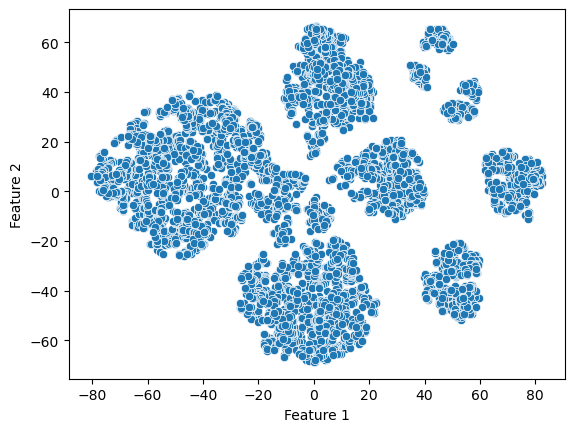

In [110]:
sns.scatterplot(data=tsne_2d_data, x="Feature 1", y="Feature 2");

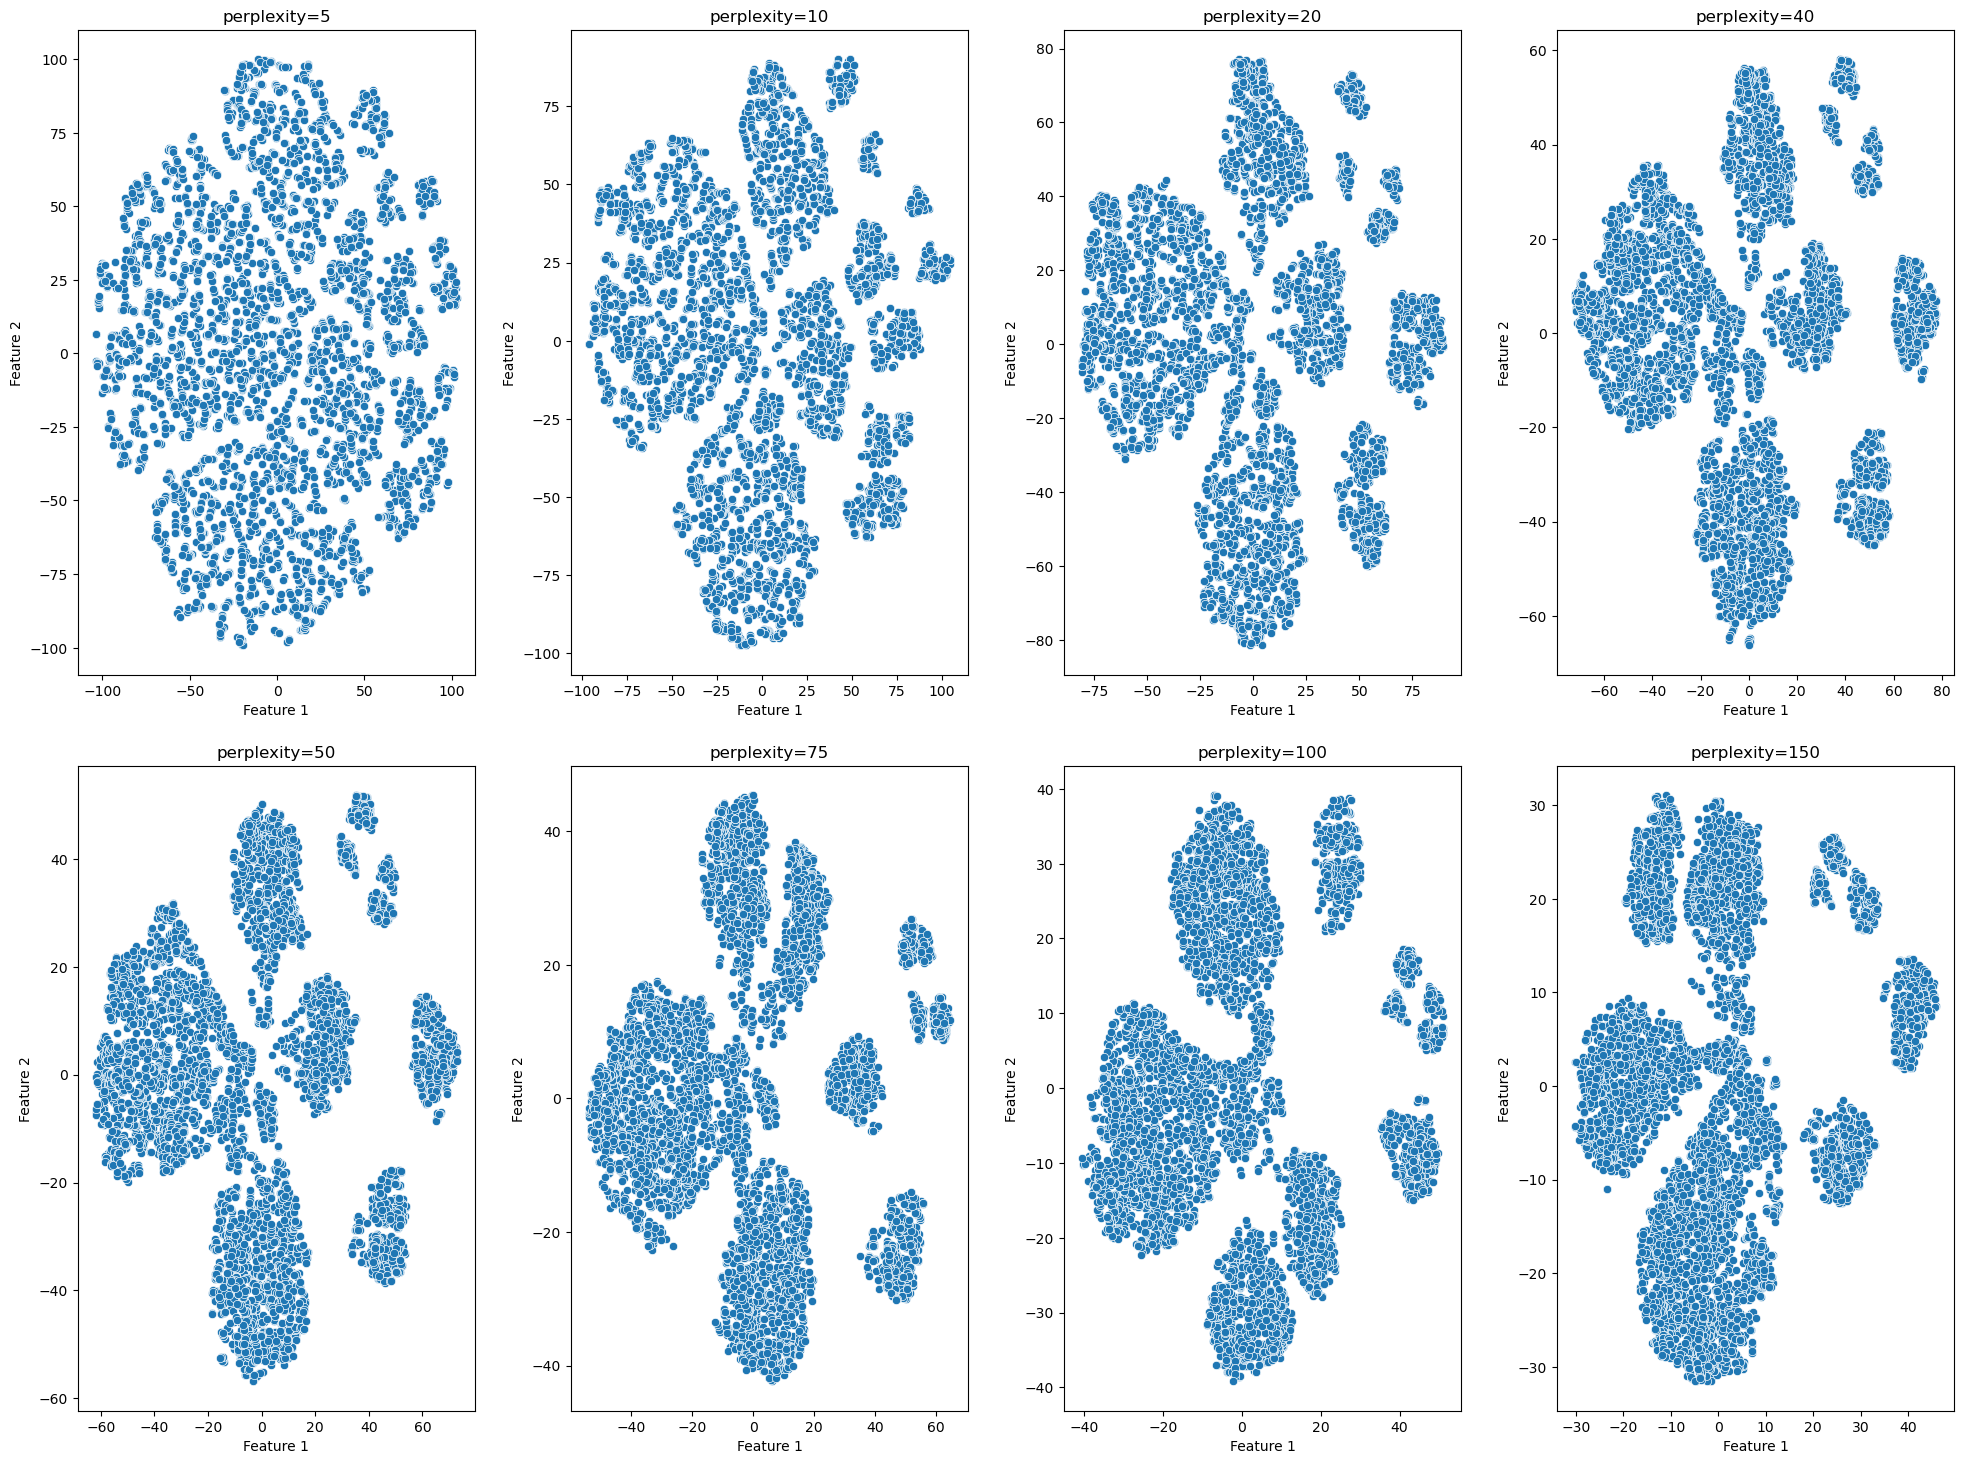

In [111]:
# Define the list of perplexity values to iterate over
perplexities = [5, 10, 20, 40, 50, 75, 100, 150]

plt.figure(figsize=(20, 15))

# Iterate over each perplexity value
for i in range(len(perplexities)):
    # Initiate TSNE with the current perplexity value
    tsne = TSNE(n_components=2, perplexity=perplexities[i], n_jobs=-2, random_state=RS)    # n_jobs specifies the nunmber of cores to use for parallel computation; -2 means use all but 1 core
    X_red = tsne.fit_transform(subset_scaled_df)   # fit_transform() fits the TSNE model to the data and transforms it into the specified number of dimensions
    red_data_df = pd.DataFrame(data=X_red, columns=["Feature 1", "Feature 2"])    # creating a new dataframe with reduced dimensions

    # Adjust the subplot grid to 2x4
    plt.subplot(2, 4, i + 1)

    plt.title("perplexity=" + str(perplexities[i]))    # setting plot title
    sns.scatterplot(data=red_data_df, x="Feature 1", y="Feature 2")
    plt.tight_layout(pad=2)

plt.show()

- Based on a 2D visualization, as a junior data scientist, I've chosen perplexity=50 with distinct 7 clusters.

In [112]:
# Initiating the t-SNE object
# n_components=2 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one processor core for parallel computation, which speeds up the process
tsne = TSNE(n_components=2, perplexity=50, n_jobs=-2, random_state=RS)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the t-SNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(subset_scaled_df)

# Creating a DataFrame from the reduced data
tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2"])) # This DataFrame will have two columns corresponding to the two reduced dimensions
tsne_2d_data.head()

,Feature 1,Feature 2
0,41.335377,-23.137505
1,46.177753,-27.682426
2,4.519158,-25.162043
3,4.676455,-17.514816
4,22.445967,-5.460898


In [114]:
#Lets reduce to 3 dimensions and visualize the data to find the number of clusters

# Initiating the TSNE object and setting output dimension to 3
# n_components=3 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one core for parallel computation, which speeds up the process
tsne = TSNE(n_components=3, perplexity=50, n_jobs=-2, random_state=RS)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the TSNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(subset_scaled_df)

# Creating a DataFrame from the reduced data
tsne_3d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2","Feature 3"])) # This DataFrame will have three columns corresponding to the three reduced dimensions

tsne_3d_data.head()

,Feature 1,Feature 2,Feature 3
0,5.274514,-11.733519,14.382811
1,4.417656,-8.757682,15.921682
2,11.047250,-7.611146,-4.087062
3,13.098191,-8.617302,-6.956755
4,6.171430,10.031754,-3.915357


In [118]:
# Now let's plot the results in a 3D scatterplot

# plotting a 3D scatterplot
fig = px.scatter_3d(tsne_3d_data, x='Feature 1', y='Feature 2', z='Feature 3')
fig.show()

- 3D visualization shows 7 clusters is about the same as visualizing clusters in 2D.  So I'm sticking with perplexity=50.

## Model Performance Improvement

In [ ]:
k_means_df = subset_scaled_df.copy()

# I'm going to try 4 to 12 clusters based in mostly 2D visualization
clusters = range(4, 12)
WCSS = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=RS)
    model.fit(subset_scaled_df) #learning stage
    prediction = model.predict(k_means_df) #assigning points to a cluster (ID)

    wcss = model.inertia_ #average distortion value


    WCSS.append(wcss)

    print("Number of Clusters:", k, "\twcss:", wcss)


Number of Clusters: 4 	wcss: 50713.922906657535
Number of Clusters: 5 	wcss: 48404.796553014305
Number of Clusters: 6 	wcss: 46993.56093949668
Number of Clusters: 7 	wcss: 44141.77400123228
Number of Clusters: 8 	wcss: 41943.49951757525
Number of Clusters: 9 	wcss: 40122.373457350004
Number of Clusters: 10 	wcss: 40227.58592590135
Number of Clusters: 11 	wcss: 38733.13319813752


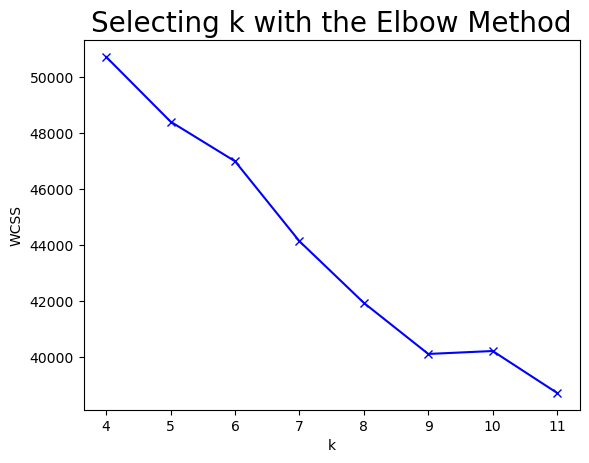

In [121]:
#Let's plot the values, x=Number of Clusters and y=wcss(aka average distortion value)

plt.plot(clusters,WCSS,"bx-")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Selecting k with the Elbow Method", fontsize=20)
plt.show()

In [ ]:
# Now let's calculate out the silhouette scores
sil_score = []
cluster_list = range(2, 10)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=RS)
    preds = clusterer.fit_predict((subset_scaled_df))
    score = silhouette_score(k_means_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

For n_clusters = 2, the silhouette score is 0.11226488321669831)
For n_clusters = 3, the silhouette score is 0.12539371315247522)
For n_clusters = 4, the silhouette score is 0.128152621807668)
For n_clusters = 5, the silhouette score is 0.11162438593252946)
For n_clusters = 6, the silhouette score is 0.09427172602103352)
For n_clusters = 7, the silhouette score is 0.10793865311562659)
For n_clusters = 8, the silhouette score is 0.12411657324637654)
For n_clusters = 9, the silhouette score is 0.12359003531675648)


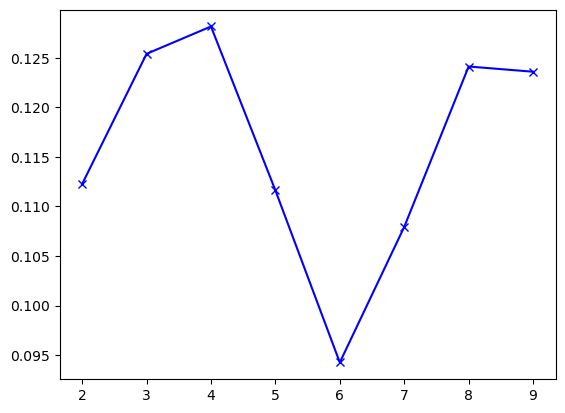

In [123]:
# Plot the silhouette scores that were calculated above
plt.plot(cluster_list, sil_score, "bx-")
plt.show()

- 4 clusters is showing the highest sil score.  This is different from the other visualization methods.  What to do?

- There's no clear winner here, so I'll go with 6.  (avg of 5.5 rounded up because why not?)

In [124]:
#Visualize final clusters

#Set up the kmeans with 6 clusters
kmeans = KMeans(n_clusters=6, random_state=RS)
kmeans.fit(k_means_df)

KMeans(n_clusters=6, random_state=0)

In [ ]:
# creating a copy of the original data
df1 = data.copy()

# adding kmeans cluster labels to the dataframes
k_means_df["K_means_segments"] = kmeans.labels_    # scaled
df1["K_means_segments"] = kmeans.labels_    # original
tsne_2d_data["K_means_segments"] = kmeans.labels_    # t-SNE 2D
tsne_3d_data["K_means_segments"] = kmeans.labels_    # t-SNE 3D

## Model Performance Comparison and Final Model Selection

## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

___